## Import data and packages

In [1]:
# Import kits/packages here
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.cluster import KMeans


In [2]:
# Load dataset
data = pd.read_csv("healthcare_risk_dataset.csv")
print(f"Data shape: {data.shape}")

Data shape: (30000, 20)


## Data cleaning and pre-processing

In [3]:
# Get information about columns
data.info()

# Retrieve column names
column_names = data.columns.tolist()

# Check for missing values
missing = data.isna().sum()
print(f"\n Number of missing values: \n{missing}")

# Age, Gender, Medical Condition, Glucose, and Blood Pressure are missing values!
# Since there isn't a significant amount missing, we can impute these missing values



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                25500 non-null  float64
 1   Gender             25500 non-null  object 
 2   Medical Condition  25500 non-null  object 
 3   Glucose            25500 non-null  float64
 4   Blood Pressure     25500 non-null  float64
 5   BMI                30000 non-null  float64
 6   Oxygen Saturation  30000 non-null  float64
 7   LengthOfStay       30000 non-null  int64  
 8   Cholesterol        30000 non-null  float64
 9   Triglycerides      30000 non-null  float64
 10  HbA1c              30000 non-null  float64
 11  Smoking            30000 non-null  int64  
 12  Alcohol            30000 non-null  int64  
 13  Physical Activity  30000 non-null  float64
 14  Diet Score         30000 non-null  float64
 15  Family History     30000 non-null  int64  
 16  Stress Level       300

In [4]:
# Create function to handle both missing numerical and categorical values

def impute_columns(df:pd.DataFrame) -> pd.DataFrame:
    
    # Get column types and save into a list
    numerical_columns = [col for col in df.columns if df[col].dtype in ["float64" or "int64"]]
    categorical_columns = [col for col in df.columns if df[col].dtype == "object"]

    # Impute numerical columns with median
    for col in numerical_columns:
        df[col] = df[col].fillna(df[col].median())

    # Impute categorical columns with mode
    for col in categorical_columns:
        df[col] = df[col].fillna(df[col].mode()[0])

    return df

In [5]:
# First, replace the missing values with NaN
data = data.replace(["NA", "N/A", "na", "n/a", "NaN", "nan", ""], np.nan)

# Impute the missing values
data = impute_columns(data)
print(f"Cleaned data: \n{data.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                30000 non-null  float64
 1   Gender             30000 non-null  object 
 2   Medical Condition  30000 non-null  object 
 3   Glucose            30000 non-null  float64
 4   Blood Pressure     30000 non-null  float64
 5   BMI                30000 non-null  float64
 6   Oxygen Saturation  30000 non-null  float64
 7   LengthOfStay       30000 non-null  int64  
 8   Cholesterol        30000 non-null  float64
 9   Triglycerides      30000 non-null  float64
 10  HbA1c              30000 non-null  float64
 11  Smoking            30000 non-null  int64  
 12  Alcohol            30000 non-null  int64  
 13  Physical Activity  30000 non-null  float64
 14  Diet Score         30000 non-null  float64
 15  Family History     30000 non-null  int64  
 16  Stress Level       300

In [6]:
# The noise_col and random_notes columns aren't needed, let's drop them
data = data.drop(["random_notes", "noise_col"], axis=1)

# Lastly, let's drop any duplicate rows to be safe
print(f"Dataset shape with duplicates: {data.shape}")
data = data.drop_duplicates().reset_index(drop=True)
print(f"Dataset without duplicates: {data.shape}")

Dataset shape with duplicates: (30000, 18)
Dataset without duplicates: (30000, 18)


In [7]:
# The "medical condition" column should be removed for this analysis because we want it to act more like a label rather than a feature
# We'll use it for labeling later to see if the unsupervised learning models clustered the data according to them, so let's save it into a new object

medical_condition_copy = data["Medical Condition"]
cleaned_data = data.drop("Medical Condition", axis=1)



## One-hot Encode Categorical Columns

Since we removed the "Medical Condition" column (temporarily), we only have to encode the "Gender" column now.

In [8]:
# Grab all remaining categorical columns left, just to be safe
cat_columns = [col for col in cleaned_data.columns if cleaned_data[col].dtype == "object"]

# One-hot encode categorical columns
encoded_columns = []

for col in cat_columns:
    # Get one-hot encoded version
    encoded = pd.get_dummies(cleaned_data[col], prefix=col, dtype=int)
    
    # Track column names
    encoded_columns.extend(encoded.columns.tolist())
    
    # Drop original and add encoded
    cleaned_data = cleaned_data.drop(col, axis=1)
    cleaned_data = pd.concat([cleaned_data, encoded], axis=1)

print(f"Cleaned data: ")
print(cleaned_data.head(10))

Cleaned data: 
    Age  Glucose  Blood Pressure    BMI  Oxygen Saturation  LengthOfStay  \
0  46.0   137.04          135.27  28.90              96.04             6   
1  22.0    71.58          113.27  26.29              97.54             2   
2  50.0    95.24          138.32  22.53              90.31             2   
3  57.0   110.50          130.53  38.47              96.60             5   
4  66.0    95.15          178.17  31.12              94.90             4   
5  50.0   107.00          171.80  25.33              95.21             5   
6  80.0   110.50          174.52  29.87              97.96             3   
7  50.0   110.50          136.13  26.37              82.72            19   
8  60.0   110.50          138.32  35.49              98.62             3   
9  13.0    90.60          126.88  29.24              97.96             6   

   Cholesterol  Triglycerides  HbA1c  Smoking  Alcohol  Physical Activity  \
0       231.88         210.56   7.61        0        0              -0.

## Scale Numerical Columns

The remaining columns have very different scales and would benefit from scaling to prevent one feature being more prominent than another.

In [9]:
# Get numeric columns now that the data is clean
num_columns = [col for col in cleaned_data.columns if cleaned_data[col].dtype in ["float64" or "int64"]]

print(f"Before scaling: ")
print(cleaned_data[num_columns].describe())

# Dictionary for means and stds
means = {}
stds = {}

for col in num_columns:
    means[col] = cleaned_data[col].mean()
    stds[col] = cleaned_data[col].std()

    # This is where the standardizing occurs
    cleaned_data[col] = (cleaned_data[col] - means[col]) / stds[col]

print(f"After scaling: ")
print(cleaned_data[num_columns].describe())

Before scaling: 
                Age       Glucose  Blood Pressure           BMI  \
count  30000.000000  30000.000000    30000.000000  30000.000000   
mean      54.674267    121.653852      140.135036     28.476155   
std       14.727541     38.617255       19.447790      5.728804   
min       10.000000     20.320000       74.240000      7.670000   
25%       47.000000     98.860000      127.730000     24.590000   
50%       55.000000    110.500000      138.320000     28.050000   
75%       64.000000    128.870000      150.630000     31.810000   
max       89.000000    318.510000      226.380000     56.850000   

       Oxygen Saturation   Cholesterol  Triglycerides         HbA1c  \
count       30000.000000  30000.000000   30000.000000  30000.000000   
mean           94.954992    213.033891     176.837375      6.294377   
std             3.736202     33.519757      48.812827      1.320269   
min            67.510000     95.730000     -22.480000      3.280000   
25%            93.000000

## Train GMM

With GMMs, you have to pre-assign the number of components or clusters for the model. The algorithm won't do this step for us so we can start with a random set of numbers and adjust as we go. To prevent overfitting, we can observe different models and evaluate which one performs best and choose k based on the AIC or BIC.

(We'll look at both later for clarity as BIC is better for true number of clusters and AIC is better to prevent overfitting).

In [10]:
# Make a function to run multiple models using pre-set parameters

def best_GMM_search(X_cleaned:pd.DataFrame, k_values:range, covariance_type="spherical", random_state=42) -> dict:
    """
    X_cleaned:pd.DataFrame - Pandas dataframe with cleaned data,
    k_values:range - range of k values that you want to loop through,
    covariance_type:str - the covariance type to be used by GaussianMixture set to "full",
    random_state:int - 42 for reproducibility
    """
    model_scores = [] # Holds the scores for each model
    bic_scores = [] # Need for BIC graph
    aic_scores = [] # Need for AIC graph

    for k in k_values:
        gmm = GaussianMixture(n_components=k, covariance_type=covariance_type, random_state=random_state)

        # train model
        gmm.fit(X_cleaned)

        # Extract BIC score
        bic = gmm.bic(X_cleaned)
        bic_scores.append(bic)

        # Extract AIC score
        aic = gmm.aic(X_cleaned)
        aic_scores.append(aic)

        # Store BIC and AIC scores in a dictionary and append to model_scores
        scores = {"k_value" : k,
                  "BIC" : bic,
                  "AIC" : aic}
        model_scores.append(scores)

    best_model_search = min(model_scores, key=lambda x: x["BIC"])

    # Return the best model
    best_k = best_model_search["k_value"]

    all_scores = {"BIC": bic_scores, "AIC" : aic_scores, "k_value" : best_k}

    return all_scores

Best k found: 10


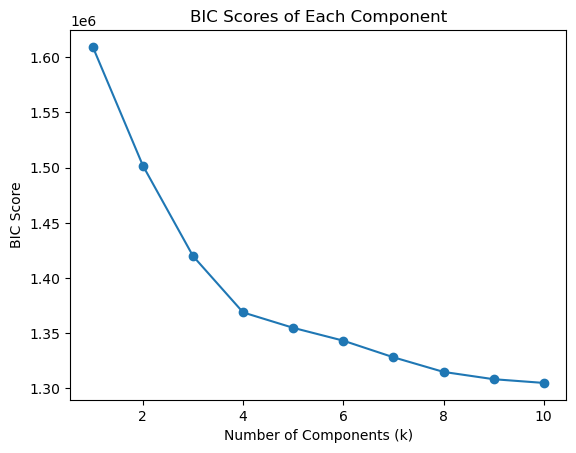

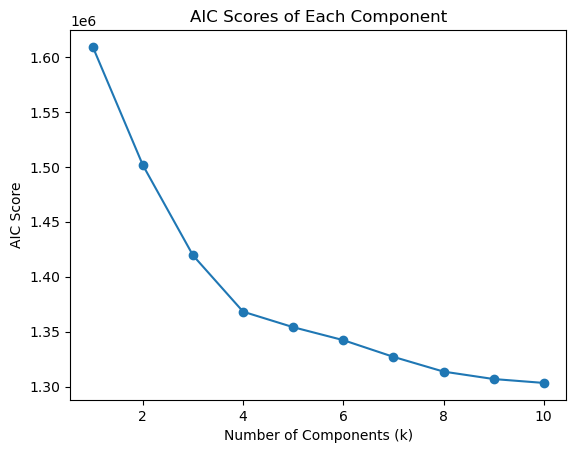

In [11]:
# Create a range of values for the components
k_values = range(1,11)

find_best_k = best_GMM_search(X_cleaned=cleaned_data, k_values=k_values)
print(f"Best k found: {find_best_k["k_value"]}")

# The algorithm thinks 10 clusters is the optimal k, but let's look at the BIC graph and AIC graph to test that
plt.plot(k_values, find_best_k["BIC"], marker="o")
plt.xlabel("Number of Components (k)")
plt.ylabel("BIC Score")
plt.title("BIC Scores of Each Component")
plt.show()

# AIC scores tend to be more flexible with complex models
plt.plot(k_values, find_best_k["AIC"], marker="o")
plt.xlabel("Number of Components (k)")
plt.ylabel("AIC Score")
plt.title("AIC Scores of Each Component")
plt.show()

Despite the lowest BIC value equating to 10 components, we'll actually use 5 as our k. This is because after 5 components, there is a very minimal decrease in BIC score. We could use 10 components but we would risk overfitting, and with a dataset this large, it could make the model more unstable. 

We also went with a "spherical" covariance type because the "full" model BIC scores demonstrated significant instability around 8-10 components, and again, we want to avoid overfitting at all costs. 

## Final Gaussian Mixture Model

Use covariance_type = "spherical", n_components = 5.

In [12]:
# Run and fit GMM using the parameters from the best model

final_gmm = GaussianMixture(n_components=5, covariance_type="spherical", random_state=42)
final_gmm.fit(cleaned_data)

# Predict the probabilities and labels for each point
labels = final_gmm.predict(cleaned_data)
probabilities = final_gmm.predict_proba(cleaned_data)

Our dataset has > 2 columns, so it can't be directly plotted onto a figure. We'll need to run a PCA to reduce the dimensionality first.

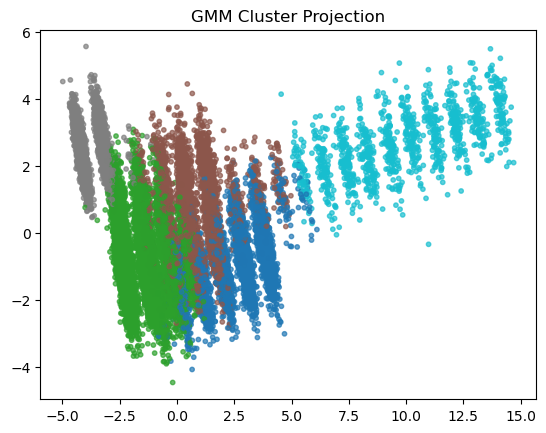

In [13]:
# Run a PCA on the cleaned data
pca = PCA(n_components=2)
fit_transform_pca = pca.fit_transform(cleaned_data)

# Plot the PCA
plt.scatter(fit_transform_pca[:, 0], fit_transform_pca[:, 1], c=labels, s=10, cmap="tab10", alpha=0.7)
plt.title("GMM Cluster Projection")
plt.show()

In [14]:
# Retrieve medical condition column from original data
med_condition_label = medical_condition_copy
print(med_condition_label.head())

0        Diabetes
1         Healthy
2          Asthma
3         Obesity
4    Hypertension
Name: Medical Condition, dtype: object


In [15]:
# Make function to plot GMM clusters with and without medical condition label
def plot_GMM_and_condition(fit_transform_pca, labels, med_condition_label) -> None:

    # Make a dataframe from the PCA, clustering labels, and the medical condition column
    df_plot = pd.DataFrame({
        "PC1" : fit_transform_pca[:, 0],
        "PC2" : fit_transform_pca[:, 1],
        "GMM Cluster" : labels,
        "Medical Condition" : med_condition_label
    })

    # Plot the GMM clusters

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.scatterplot(
        x="PC1",
        y="PC2",
        hue="GMM Cluster",
        palette="tab10",
        data=df_plot,
        s=40,
        alpha=0.7,
        ax=axes[0]
    )

    axes[0].set_title("GMM Cluster Assignments")

    # Plotting with the medical condition now
    sns.scatterplot(
        x="PC1",
        y="PC2",
        hue="Medical Condition",
        palette="tab10",
        data=df_plot,
        s=40,
        alpha=0.7,
        ax=axes[1]
    )

    axes[1].set_title("GMM Coloured by Medical Condition")

    for ax in axes:
        ax.set_xlabel("Component 1")
        ax.set_ylabel("Component 2")

    plt.tight_layout()
    plt.show()

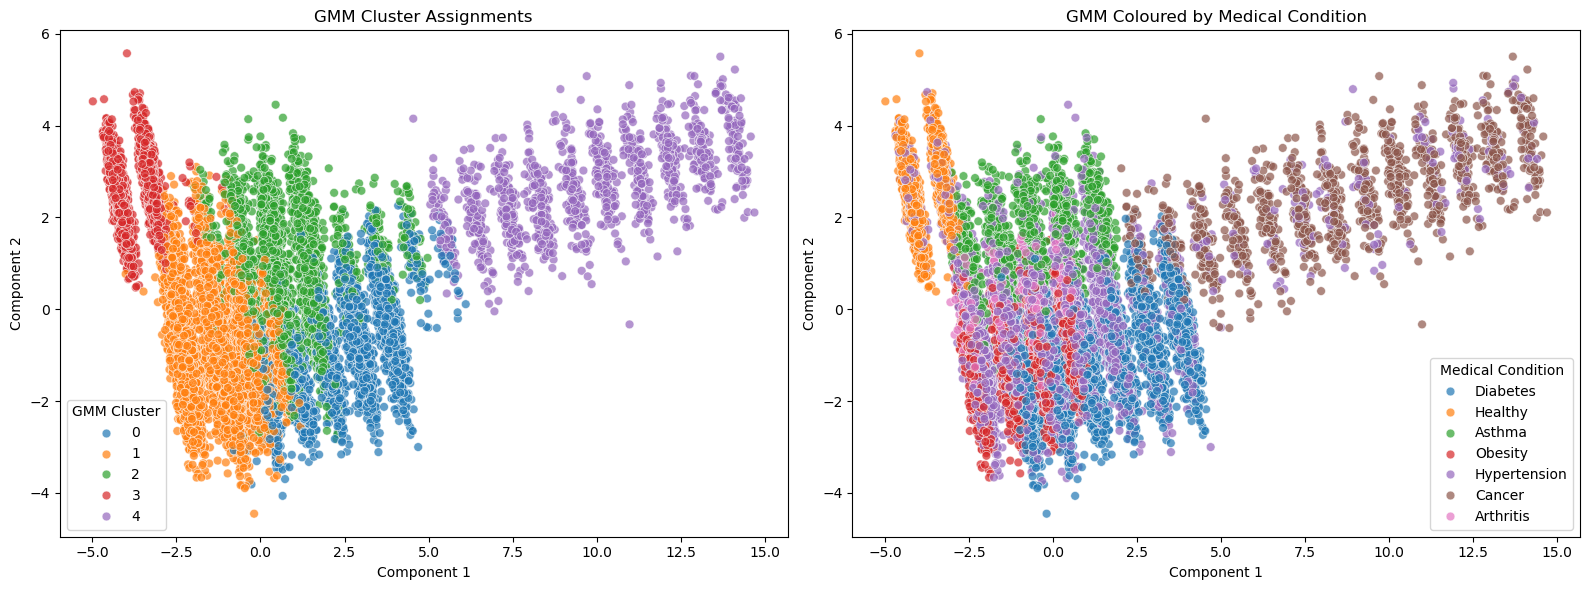

In [16]:
plot_GMM_and_condition(fit_transform_pca=fit_transform_pca, labels=labels, med_condition_label=med_condition_label)

## K-Means Comparison

Now let's visualize the data using K-means clustering and compare the output to the GMM. For fairness, we'll use the same k (5).

In [17]:
# Run and fit the K-means model

kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit_predict(cleaned_data)

# Retrieve the labels
kmeans_labels = kmeans.labels_

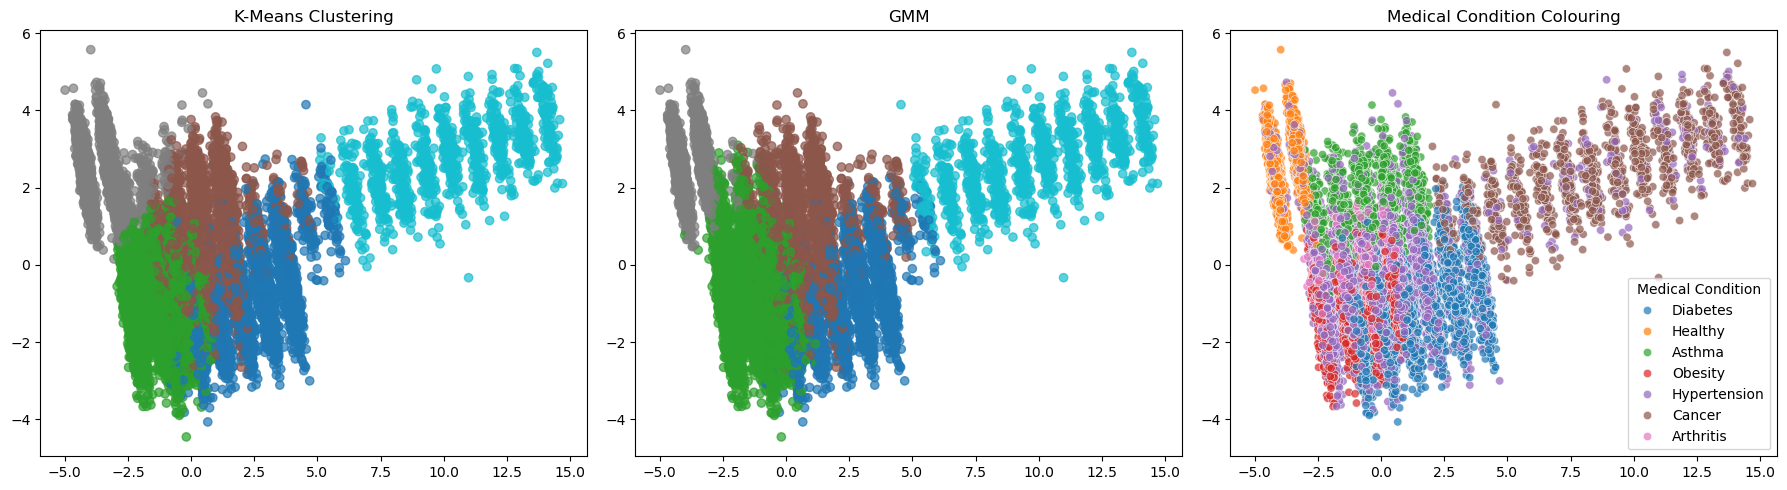

In [ ]:
# We can re-use the PCA for dimensionality reduction

fig, axes = plt.subplots(1,3, figsize=(18,5))

# Plot the Kmeans
axes[0].scatter(fit_transform_pca[:,0], fit_transform_pca[:,1], c=kmeans_labels, cmap="tab10", alpha=0.7)
axes[0].set_title("K-Means Clustering")

# Plot the GMM
axes[1].scatter(fit_transform_pca[:,0], fit_transform_pca[:,1], c=labels, cmap="tab10", alpha=0.7)
axes[1].set_title("GMM")

# Plot the GMM with the Medical Condition colouring
sns.scatterplot(x=fit_transform_pca[:,0], y=fit_transform_pca[:,1], hue=med_condition_label, palette="tab10", alpha=0.7, ax=axes[2])
axes[2].set_title("Medical Condition Colouring")

plt.tight_layout()
plt.show()